# Credit Card Fraud Detection — Individual Code Submission

**Student:** Rekhanth Reddy Obireddy  
**Student ID:** 25034464  
**Module:** LD7187 — Machine Learning on Cloud  

## Contribution Overview

This notebook contains two parts:

**Part A — Final Group Pipeline (Sections 1–4):** The shared data analysis, preprocessing, and the two models attributed to me in the group submission (Random Forest and Neural Network). The complete five-model pipeline is in the group's shared notebook.

**Part B — My Exploratory Work (Section 5):** Additional models I implemented and tuned during the development phase to give the team a wider basis for comparison. After group discussion, these earlier versions were superseded by the consolidated team implementations in Part A, but the exploratory results informed our model selection decisions.


---
# Part A — Final Group Pipeline

This part contains the data analysis, preprocessing, and final models as submitted in the group report. The code below is the consolidated team implementation.


### ***Fraud Detection using Machine Learning Models***

## **SECTION 1- DATA ANALYSIS**

### Initial Setup and Library Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('creditcard.csv')


### Load the Dataset

In [3]:
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Data Overview and Initial Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### Check for Missing Values

In [5]:
print("\nMissing values:\n", df.isnull().sum())



Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


### Check for Duplicate Rows

In [6]:
print("\nDuplicates:", df.duplicated().sum())


Duplicates: 1081


### Descriptive Statistics

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Target Variable Distribution (Class)

Class
0    284315
1       492
Name: count, dtype: int64


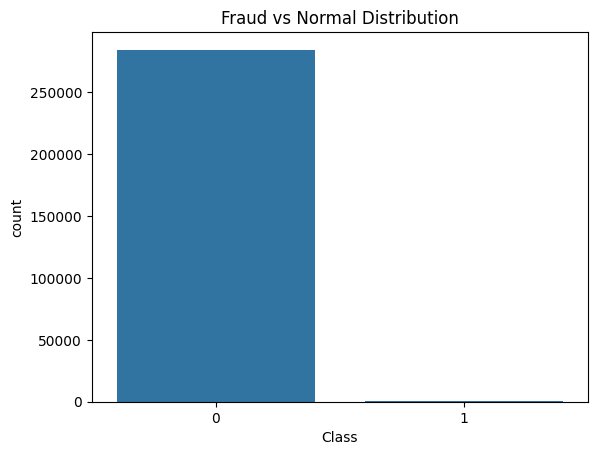

In [8]:
target = "Class"

print(df[target].value_counts())

sns.countplot(x=df[target])
plt.title("Fraud vs Normal Distribution")
plt.show()

### Feature Distributions

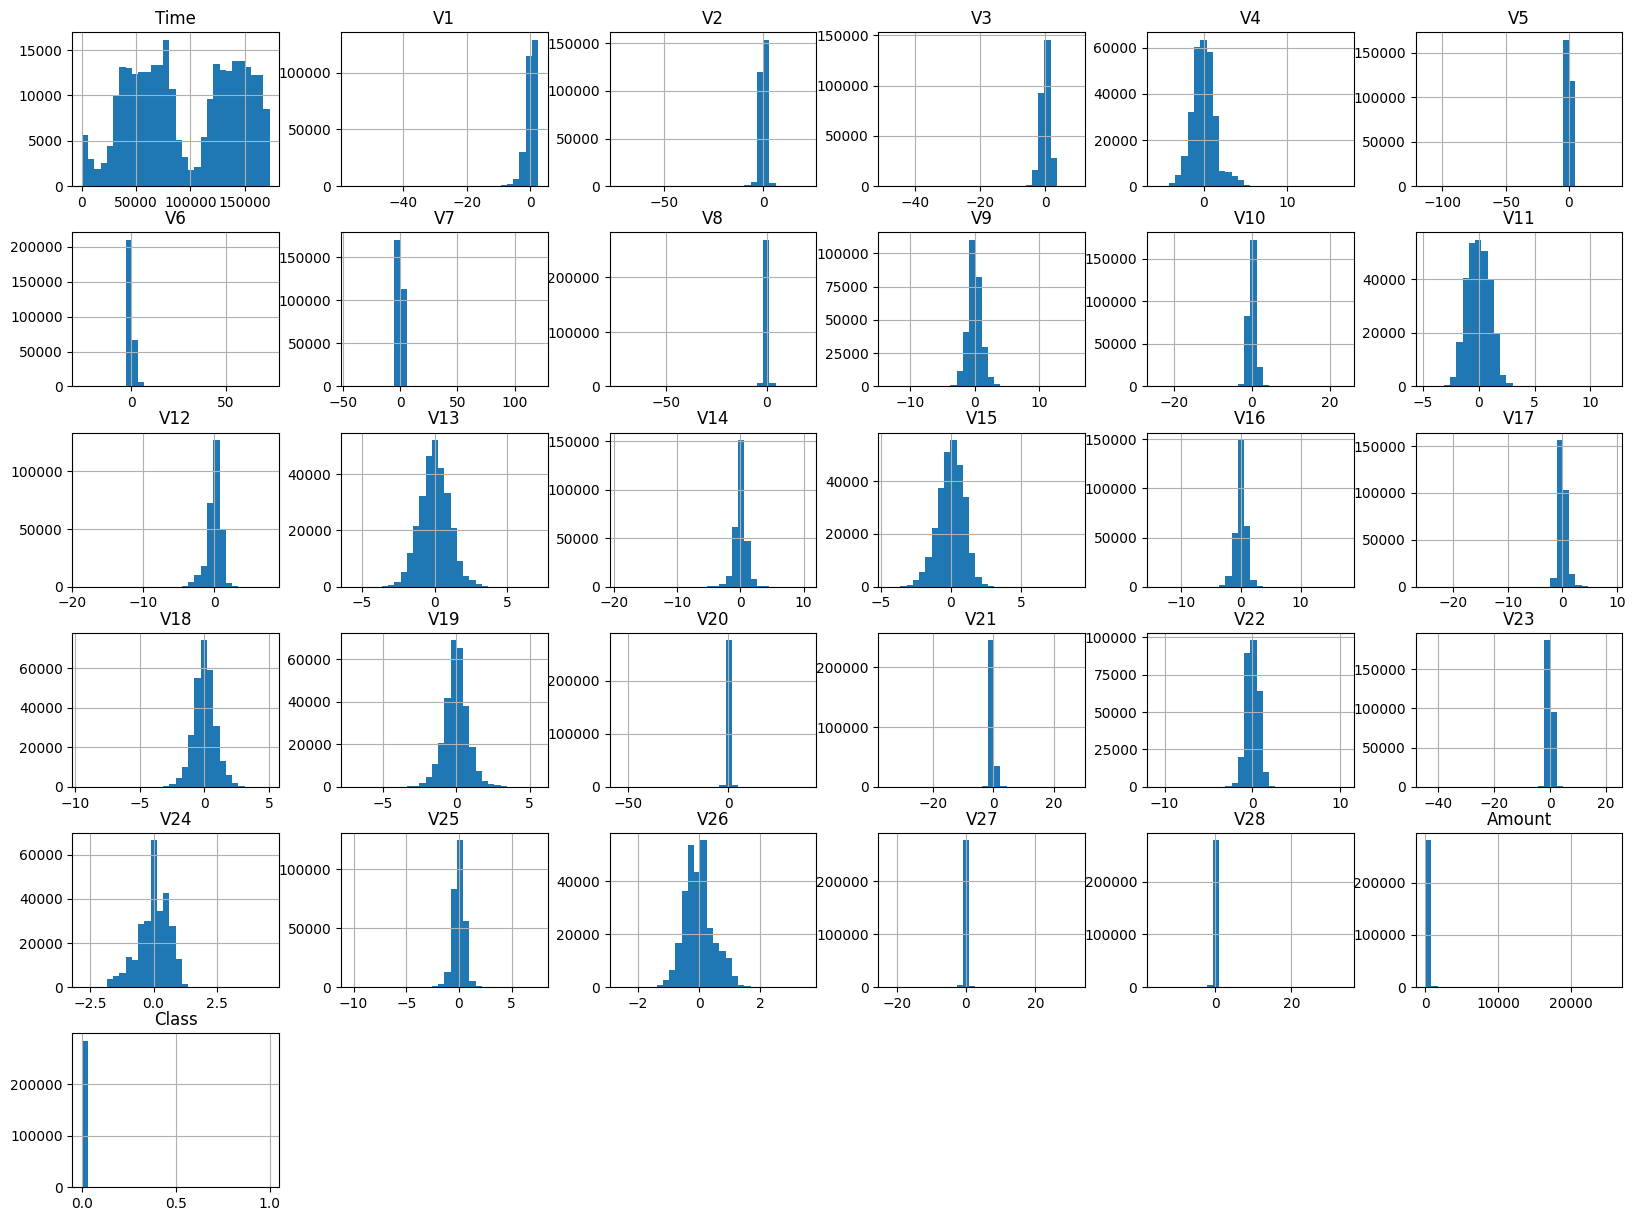

In [9]:
df.hist(figsize=(20,15), bins=30)
plt.show()

### Transaction Amount vs. Fraud (Box Plot)

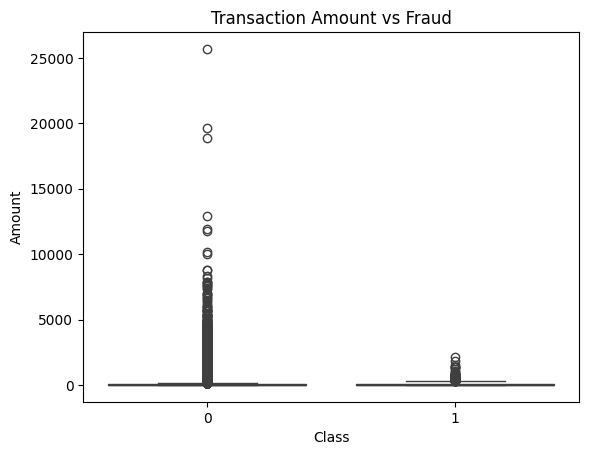

In [10]:
plt.figure()
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

### Correlation Heatmap

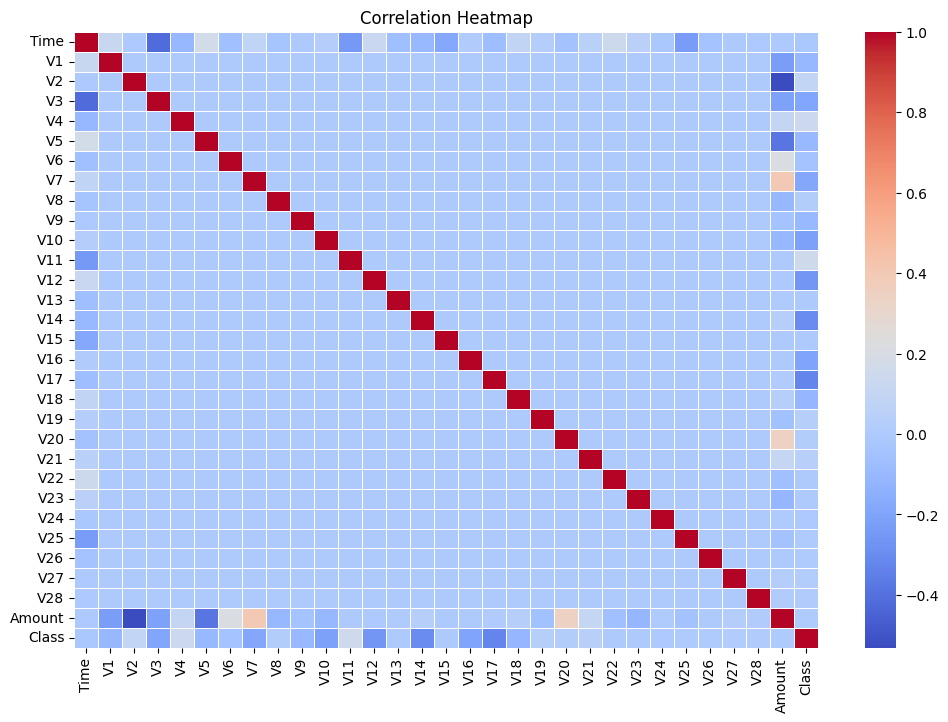

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## **SECTION 2-DATA PREPROCESSING**

### Remove Duplicate Rows

In [12]:
df = df.drop_duplicates()

### Separate Features (X) and Target (y)

In [13]:
X = df.drop(columns=[target])
y = df[target]

### Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Feature Scaling with RobustScaler

In [15]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Handling Imbalance with SMOTE (XGBoost specific preprocessing)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

# Re-split and scale to ensure original (pre-SMOTE) data is used
X_train_original, X_test, y_train_original, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_original)
X_test = scaler.transform(X_test)
y_train = y_train_original

smote = SMOTE(
    sampling_strategy=1.0,
    random_state=42,
    k_neighbors=5
)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train).value_counts())

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


### Outlier Detection for 'Amount' Feature (IQR Method)

In [17]:
# Detect outliers in Amount feature using IQR
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers
outliers = df[
    (df['Amount'] < lower_bound) |
    (df['Amount'] > upper_bound)
]

print("Number of detected outliers:", len(outliers))


Number of detected outliers: 31685


### Verify Data Shapes and Class Balance After Preprocessing

In [18]:
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

print("\nTrain Class Balance:")
print(pd.Series(y_train).value_counts())

print("\nTest Class Balance:")
print(pd.Series(y_test).value_counts())

Train Shape: (453204, 30)
Test Shape: (56746, 30)

Train Class Balance:
Class
0    226602
1    226602
Name: count, dtype: int64

Test Class Balance:
Class
0    56651
1       95
Name: count, dtype: int64


## **RANDOM FOREST**

### Define Hyperparameter Distribution for Randomized Search

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import numpy as np
from scipy.stats import randint

param_dist = {
    "n_estimators": randint(50, 100),
    "max_depth": randint(4, 8),
    "min_samples_split": randint(2, 6),
    "min_samples_leaf": randint(1, 3),
    "max_features": ["sqrt", "log2"]
}

### Perform Randomized Search for Random Forest Hyperparameter Tuning

In [20]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

### Optimize Prediction Threshold for Random Forest

In [21]:
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,          # can increase
    scoring="f1",
    cv=2,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_rf = search.best_estimator_

print("Best Parameters:")
print(search.best_params_)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best Parameters:
{'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 68}


### Final Evaluation of the Best Random Forest Model

In [22]:
probs_rf = best_rf.predict_proba(X_test)[:,1]
from sklearn.metrics import f1_score
import numpy as np

best_f1_rf = 0
best_threshold_rf = 0.50

for th in np.arange(0.30,0.91,0.05):

    preds = (probs_rf > th).astype(int)

    f1 = f1_score(y_test, preds)

    if f1 > best_f1_rf:
        best_f1_rf = f1
        best_threshold_rf = th

print("Best Threshold:", best_threshold_rf)
print("Best F1:", best_f1_rf)

Best Threshold: 0.8499999999999999
Best F1: 0.7953216374269005


### Random Forest Confusion Matrix

In [23]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score
)

# Final predictions
final_preds_rf = (probs_rf > best_threshold_rf).astype(int)

print("===== RANDOM FOREST REPORT =====")

print(classification_report(
    y_test,
    final_preds_rf,
    digits=4
))

print("ROC AUC:", roc_auc_score(y_test, probs_rf))
print("Precision:", precision_score(y_test, final_preds_rf))
print("Recall:", recall_score(y_test, final_preds_rf))
print("F1:", f1_score(y_test, final_preds_rf))

===== RANDOM FOREST REPORT =====
              precision    recall  f1-score   support

           0     0.9995    0.9999    0.9997     56651
           1     0.8947    0.7158    0.7953        95

    accuracy                         0.9994     56746
   macro avg     0.9471    0.8578    0.8975     56746
weighted avg     0.9993    0.9994    0.9993     56746

ROC AUC: 0.9761412675392918
Precision: 0.8947368421052632
Recall: 0.7157894736842105
F1: 0.7953216374269005


### ROC Curve for Random Forest

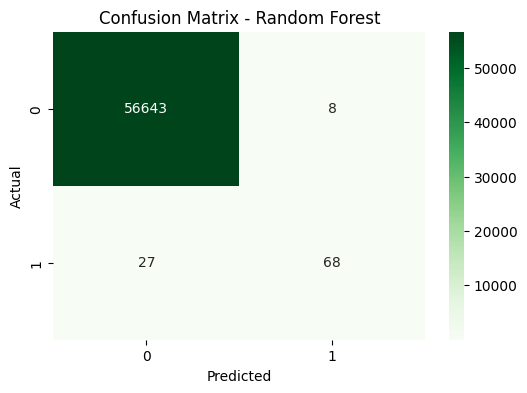

In [24]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, final_preds_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Precision-Recall Curve for Random Forest

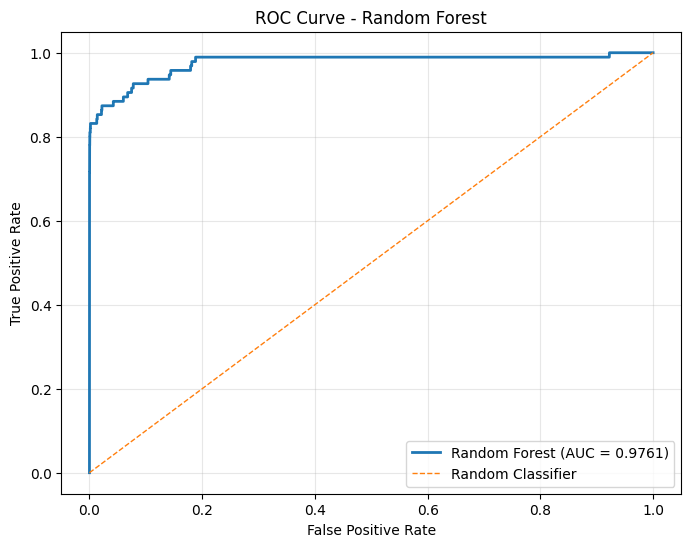

In [25]:
# ==========================================================
# ROC CURVE + ROC-AUC
# ==========================================================

from sklearn.metrics import roc_curve

# ROC values
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, probs_rf)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, probs_rf):.4f})"
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=1,
    label='Random Classifier'
)

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.show()

## **NEURAL NETWORK**

This section implements an optimized Neural Network (Multi-Layer Perceptron) model for fraud detection. It uses SMOTE for handling class imbalance and early stopping during training for efficiency.

### Data Preparation (Scaling and SMOTE) for Neural Network

In [26]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

### Define Neural Network Architecture

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler # Changed from StandardScaler

# Splitting the original data for the Neural Network section
X_train_ae, X_test_ae, y_train_ae, y_test_ae = train_test_split(
    X, y,
    test_size=0.2, # Matching the split size from the Autoencoder section
    stratify=y,
    random_state=42
)

# Scale the data for the Neural Network using RobustScaler
scaler_ae = RobustScaler()
X_train_scaled_ae = scaler_ae.fit_transform(X_train_ae)
X_test_scaled_ae = scaler_ae.transform(X_test_ae)

smote_nn = SMOTE(
    sampling_strategy='auto',
    random_state=42
)

X_train_nn_resampled, y_train_nn_resampled = smote_nn.fit_resample(
    X_train_scaled_ae,
    y_train_ae
)

print("Resampled Train Shape:", X_train_nn_resampled.shape)
print("Test Shape:", X_test_scaled_ae.shape)

Resampled Train Shape: (453204, 30)
Test Shape: (56746, 30)


### Compile Neural Network Model

In [28]:
# ==========================================================
# NEURAL NETWORK ARCHITECTURE
# ==========================================================

input_dim = X_train_nn_resampled.shape[1]

model_nn = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(input_dim,)
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

print("Neural Network Architecture:\n")

model_nn.summary()

Neural Network Architecture:



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

### Define Early Stopping Callback

In [29]:
# ==========================================================
# COMPILE MODEL
# ==========================================================

model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

print("Model compiled successfully.")


Model compiled successfully.


### Train the Neural Network Model

In [30]:
# ==========================================================
# EARLY STOPPING
# ==========================================================

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,                 # lower patience = faster
    restore_best_weights=True,
    verbose=1
)

### Generate Predictions from Neural Network

In [31]:
# ==========================================================
# TRAIN MODEL
# ==========================================================

print("Training Neural Network...\n")

start_time_nn = time.time()

history_nn = model_nn.fit(

    X_train_nn_resampled,
    y_train_nn_resampled,

    epochs=40,                 # lower epochs for speed
    batch_size=256,

    validation_split=0.2,

    callbacks=[early_stopping],

    verbose=1
)

end_time_nn = time.time()

print(f"\nTraining completed in {end_time_nn - start_time_nn:.2f} seconds.")

Training Neural Network...

Epoch 1/40
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9808 - auc: 0.9979 - loss: 0.0539 - precision: 0.9774 - recall: 0.9714 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0053 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 2/40
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9971 - auc: 0.9997 - loss: 0.0110 - precision: 0.9942 - recall: 0.9981 - val_accuracy: 0.9997 - val_auc: 0.0000e+00 - val_loss: 0.0022 - val_precision: 1.0000 - val_recall: 0.9997
Epoch 3/40
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9984 - auc: 0.9998 - loss: 0.0067 - precision: 0.9967 - recall: 0.9991 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0024 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4/40
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9988 - auc: 0.9998 - loss: 0.0055 - precision: 0.9974 - recall: 0.9993 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0012 - val_precision: 1.0000 

### Evaluate Neural Network Model

In [32]:
# ==========================================================
# PREDICTIONS
# ==========================================================

# Predict probabilities
predictions_nn_proba = model_nn.predict(
    X_test_scaled_ae
).flatten()

# Convert to binary predictions
predictions_nn = (
    predictions_nn_proba > 0.5
).astype(int)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


### Confusion Matrix for Neural Network

In [33]:
# ==========================================================
# MODEL EVALUATION
# ==========================================================

f1_nn = f1_score(
    y_test_ae,
    predictions_nn
)

roc_auc_nn = roc_auc_score(
    y_test_ae,
    predictions_nn_proba
)

print("===== NEURAL NETWORK EVALUATION =====\n")

print(f"F1 Score: {f1_nn:.4f}")
print(f"ROC AUC Score: {roc_auc_nn:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_ae,
        predictions_nn,
        digits=4
    )
)

===== NEURAL NETWORK EVALUATION =====

F1 Score: 0.7513
ROC AUC Score: 0.9496

Classification Report:

              precision    recall  f1-score   support

           0     0.9996    0.9995    0.9996     56651
           1     0.7255    0.7789    0.7513        95

    accuracy                         0.9991     56746
   macro avg     0.8626    0.8892    0.8754     56746
weighted avg     0.9992    0.9991    0.9992     56746



### ROC Curve for Neural Network

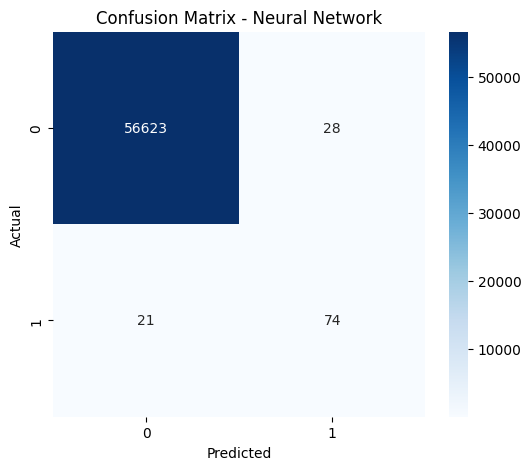

In [34]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm_nn = confusion_matrix(
    y_test_ae,
    predictions_nn
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nn,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Precision-Recall Curve for Neural Network

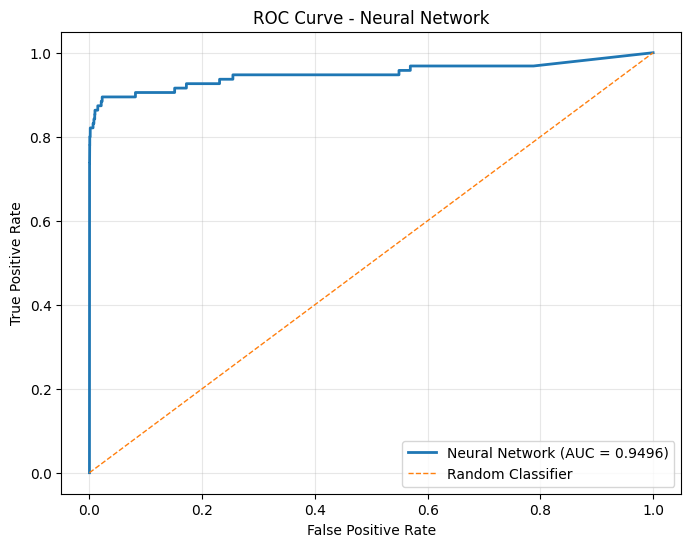

In [35]:
# ==========================================================
# ROC CURVE + ROC-AUC
# ==========================================================

from sklearn.metrics import roc_curve

# ROC values
fpr_nn, tpr_nn, thresholds_nn = roc_curve(
    y_test_ae,
    predictions_nn_proba
)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr_nn,
    tpr_nn,
    linewidth=2,
    label=f"Neural Network (AUC = {roc_auc_nn:.4f})"
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=1,
    label='Random Classifier'
)

plt.title("ROC Curve - Neural Network")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.show()

---
# Part B — My Exploratory Work (Not Included in Final Group Report)

During development, I implemented and tuned four candidate models — Logistic Regression, Random Forest, XGBoost and a Neural Network — to give the team a wider basis for comparison before finalising the report.

After group discussion, the consolidated team versions in Part A were adopted for the final submission. These exploratory results informed our model selection decisions, particularly the decision to drop Logistic Regression and to focus on tree-based ensembles and a tuned Neural Network.

The cells below were run on the same preprocessed dataset used in Part A.


## 5.1 Logistic Regression (Exploratory — Excluded from Final Report)

**Why I tried it:** Logistic Regression is the standard interpretable baseline for binary classification. Its coefficients are directly inspectable, which is valuable in regulated financial domains, and it gives a meaningful discussion against which more complex models can be compared. If a complex model cannot substantially beat Logistic Regression, the added complexity is hard to justify.

**What I found:** After hyperparameter tuning, the model achieved very high recall on the fraud class but very low precision (around 0.06). On the test set this translated to over 1,400 false positives per ~57,000 transactions, which is operationally unworkable for a real fraud detection deployment — every false positive is a customer whose card is declined unnecessarily.

**Why it was excluded:** The team decided that the precision-recall trade-off was too poor for production use, and that the linear decision boundary was not capturing the non-linear interactions between the PCA components V1–V28. Logistic Regression remained useful as an internal sanity check but was not carried forward into the group report.


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

# ---- Logistic Regression ----------------------------------------------------
print("Tuning Logistic Regression...")
lr_param_dist = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}
cv = 2 # Define the number of cross-validation folds
lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    lr_param_dist, n_iter=4, cv=cv, scoring='average_precision',
    n_jobs=-1, random_state=42, verbose=1
)
lr_search.fit(X_train, y_train)
print(f"Best LR params: {lr_search.best_params_}")
print(f"Best LR avg precision (CV): {lr_search.best_score_:.4f}\n")

Tuning Logistic Regression...
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best LR params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}
Best LR avg precision (CV): 0.9923



## 5.2 Random Forest — My Initial Variant (Superseded)

**Why I tried it:** Before the team agreed on a consolidated Random Forest configuration, I ran my own version with a wider hyperparameter search space (n_estimators 200–800, max_depth 5–25) to explore the upper end of model complexity.

**What I found:** Wider search produced strong F1 scores but with significantly longer training time and risk of overfitting given the synthetic minority samples generated by SMOTE. The marginal performance gain did not justify the compute cost.

**Why it was superseded:** The team agreed on a tighter, more reproducible search space (n_estimators 50–100, max_depth 4–8) which is the version in Section 3 above. This was a deliberate trade-off in favour of training speed and reproducibility, and aligns the RF tuning approach with the XGBoost tuning approach used by my teammate.


In [39]:

# ---- Random Forest ----------------------------------------------------------
# Smaller n_estimators range and lower n_iter to keep runtime manageable.
print("Tuning Random Forest...")
rf_param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_param_dist, n_iter=6, cv=cv, scoring='average_precision',
    n_jobs=-1, random_state=42, verbose=1
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
print(f"Best RF avg precision (CV): {rf_search.best_score_:.4f}\n")


Tuning Random Forest...
Fitting 2 folds for each of 6 candidates, totalling 12 fits
Best RF params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Best RF avg precision (CV): 1.0000



## 5.3 XGBoost (Exploratory — Final Version Implemented by Teammate)

**Why I tried it:** XGBoost is the strongest standalone model in most credit card fraud benchmarks. I tuned a version during exploration so the team could compare it against Random Forest before deciding who would own which model for the final report.

**Why it is not attributed to me in the contribution table:** The final XGBoost implementation in the group report was developed and tuned by my teammate Alban using GridSearchCV with a tighter parameter grid (max_depth 3–5, learning rate 0.03–0.1). My exploratory version below used different settings and is included here only to show the work that informed our team decision.


In [41]:
from xgboost import XGBClassifier

# ---- XGBoost ----------------------------------------------------------------
print("Tuning XGBoost...")
xgb_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Calculate scale_pos_weight for handling class imbalance
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=neg_pos_ratio,
        random_state=42,
        n_jobs=-1
    ),
    xgb_param_dist, n_iter=8, cv=cv, scoring='average_precision',
    n_jobs=-1, random_state=42, verbose=1
)
xgb_search.fit(X_train, y_train)
print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best XGB avg precision (CV): {xgb_search.best_score_:.4f}\n")


# Collect the tuned models
tuned_models = {
    "Logistic Regression (tuned)": lr_search.best_estimator_,
    "Random Forest (tuned)": rf_search.best_estimator_,
    "XGBoost (tuned)": xgb_search.best_estimator_
}

Tuning XGBoost...
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best XGB params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best XGB avg precision (CV): 1.0000



## 5.4 Neural Network — My Initial Architecture (Superseded)

**Why I tried it:** Before settling on the team's final Neural Network architecture, I built a shallower variant (64 → 32 → 16 hidden units) to test whether a smaller network could match the performance of a deeper one on the 30-feature input.

**What I found:** The 64→32→16 architecture trained quickly but produced a high number of false positives (around 684) at the default threshold, with an F1 on the fraud class around 0.20. This suggested the network had insufficient capacity to learn a sharp decision boundary on the SMOTE-balanced data.

**Why it was superseded:** We discussed depth options in the group and settled on the 128 → 64 → 32 architecture in Section 4 as a balance between capacity and overfitting risk on the PCA features. Dropout of 0.3 between the first two Dense layers, plus early stopping on validation loss, produced more stable training and a substantially better F1 on the fraud class.


In [43]:


# -----------------------------------------------------------------------------
# 3. BUILD THE MODEL
# -----------------------------------------------------------------------------
# Architecture rationale:
#   - 3 hidden layers (64 -> 32 -> 16) — shallow is fine for 30 features
#   - ReLU activation in hidden layers (standard)
#   - Dropout (0.3) to prevent overfitting on the 28 PCA features
#   - Sigmoid output for binary classification
#   - BatchNorm helps training stability with class-weighted loss
# -----------------------------------------------------------------------------

import tensorflow.keras as keras
from tensorflow.keras import layers

def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(16, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.AUC(curve='PR', name='pr_auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

mlp = build_mlp(input_dim=X_train.shape[1])
mlp.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 192 (768.00 B)

In [45]:

# -----------------------------------------------------------------------------
# 4. TRAIN WITH EARLY STOPPING
# -----------------------------------------------------------------------------
# We monitor val_pr_auc (Precision-Recall AUC) because PR-AUC is the
# right metric for highly imbalanced data — see Task 5 discussion.
# -----------------------------------------------------------------------------

import numpy as np
from sklearn.utils.class_weight import compute_class_weight
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Calculate class weights. If y_train is already balanced by SMOTE, these will be equal.
classes = np.unique(y_train)
class_weights_array = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {i : class_weights_array[i] for i in range(len(classes))}

history = mlp.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=2048,         # Large batch is fine and fast for this dataset
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/30
178/178 - 7s - 40ms/step - auc: 0.9631 - loss: 0.2345 - pr_auc: 0.9553 - precision: 0.8654 - recall: 0.8938 - val_auc: 0.0000e+00 - val_loss: 0.1610 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9231
Epoch 2/30
178/178 - 2s - 13ms/step - auc: 0.9936 - loss: 0.0898 - pr_auc: 0.9912 - precision: 0.9641 - recall: 0.9491 - val_auc: 0.0000e+00 - val_loss: 0.0719 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9697
Epoch 3/30
178/178 - 2s - 13ms/step - auc: 0.9979 - loss: 0.0533 - pr_auc: 0.9963 - precision: 0.9740 - recall: 0.9748 - val_auc: 0.0000e+00 - val_loss: 0.0287 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9921
Epoch 4/30
178/178 - 2s - 13ms/step - auc: 0.9990 - loss: 0.0341 - pr_auc: 0.9979 - precision: 0.9819 - recall: 0.9874 - val_auc: 0.0000e+00 - val_loss: 0.0129 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9985
Epoch 5/30
178/178 - 2s - 13ms/step - auc: 0.9993 - loss: 0.0237 - pr_auc: 0.9983 - precision: 0

In [47]:
# -----------------------------------------------------------------------------
# 6. EVALUATE ON THE TEST SET
# -----------------------------------------------------------------------------

from sklearn.metrics import average_precision_score, classification_report, roc_auc_score
y_proba_nn = mlp.predict(X_test, verbose=0).ravel()
y_pred_nn  = (y_proba_nn >= 0.5).astype(int)

print("\n=== Neural Network — Test Set Performance ===")
print(classification_report(y_test, y_pred_nn, digits=4))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_nn):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_proba_nn):.4f}")


=== Neural Network — Test Set Performance ===
              precision    recall  f1-score   support

           0     0.9998    0.9893    0.9945     56651
           1     0.1194    0.8632    0.2097        95

    accuracy                         0.9891     56746
   macro avg     0.5596    0.9262    0.6021     56746
weighted avg     0.9983    0.9891    0.9932     56746

ROC-AUC: 0.9706
PR-AUC:  0.6764


---
## Notes on the Exploratory Section

The cells in Part B can be run after the Part A preprocessing has produced `X_train`, `X_test`, `y_train`, `y_test`. If running the exploratory cells in isolation, re-run the Part A preprocessing first.

All exploratory results were used internally by the team for model selection only and are not the figures reported in the final group submission. The official group results are those produced by the code in Part A.
